Ergebnisse visualisieren

Imports

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Plots

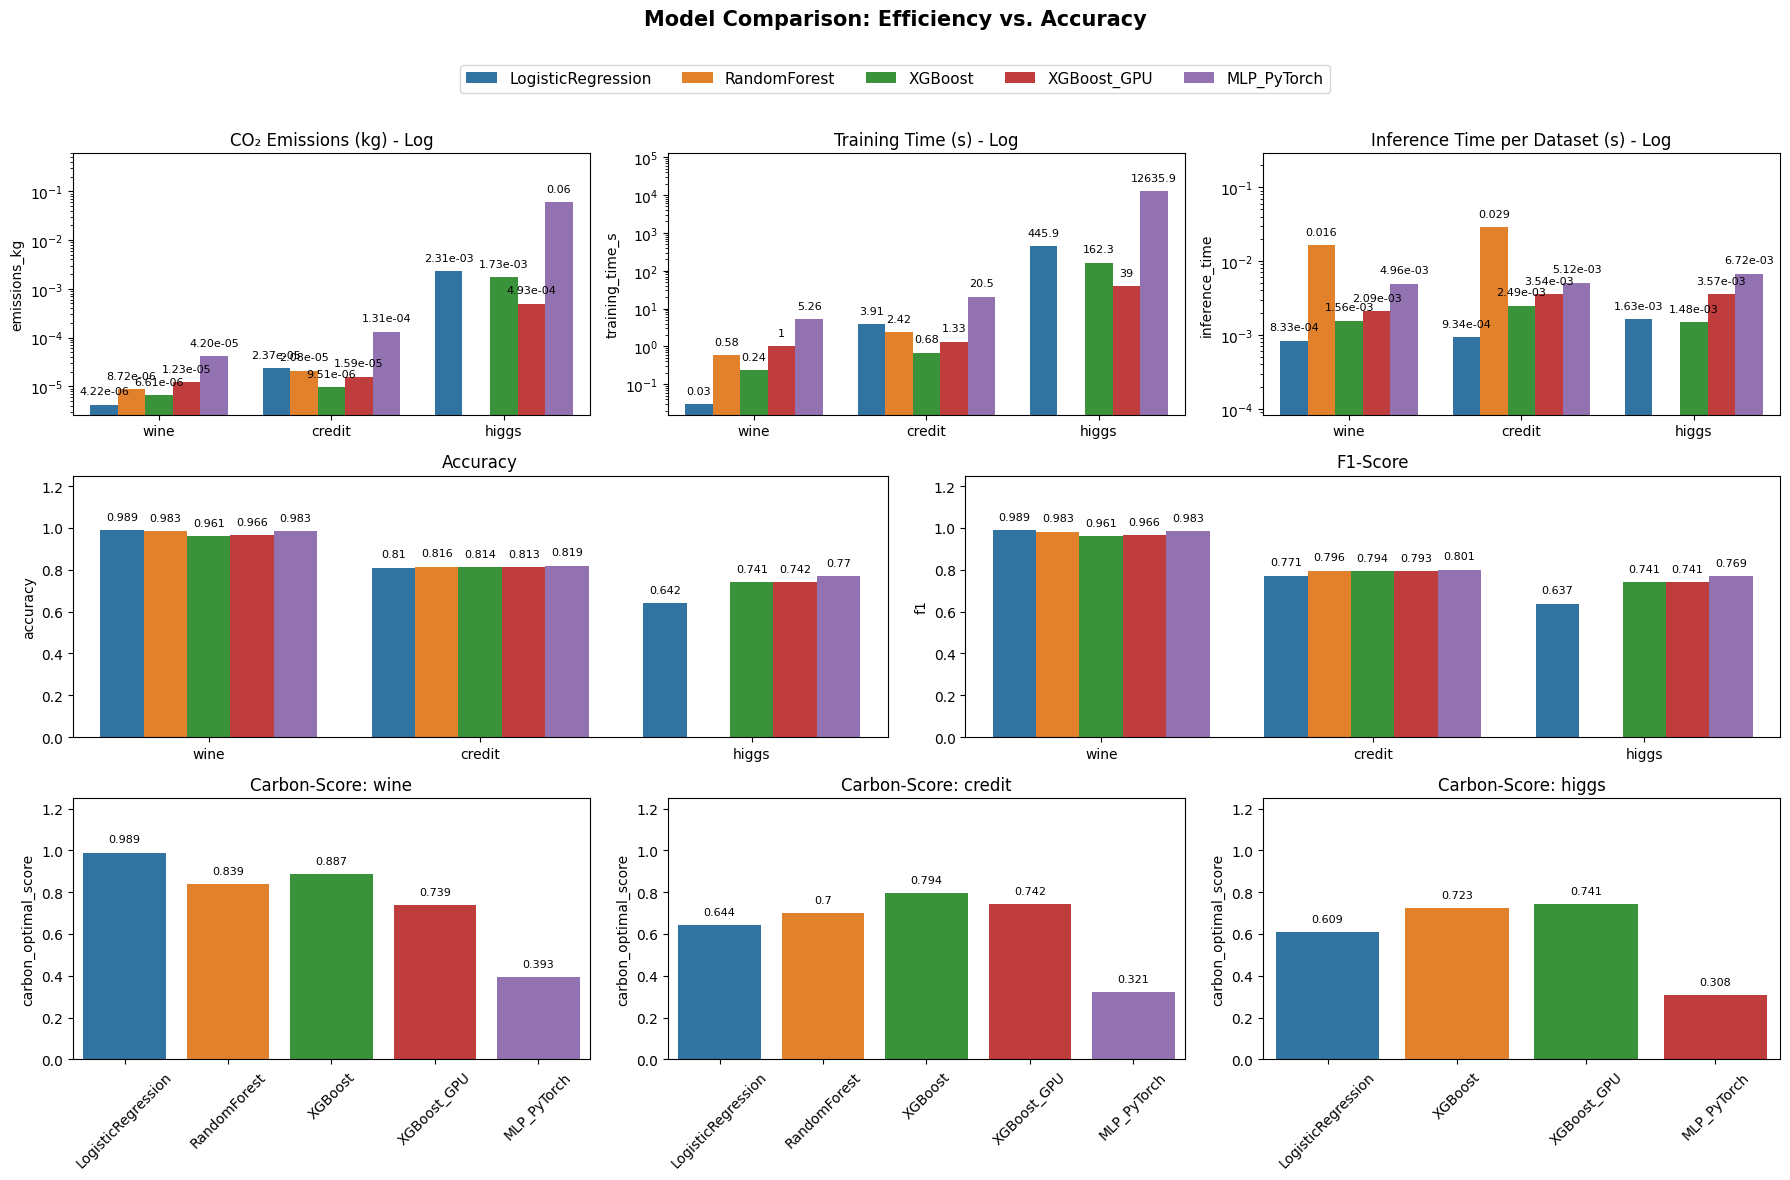

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.read_csv("../results/results.csv")
df_inf = pd.read_csv("../results/inference_time.csv")
df_results.columns = df_results.columns.str.strip()
df_inf.columns = df_inf.columns.str.strip()

df_results["dataset"] = df_results["dataset"].astype(str).str.strip()
df_results["model"] = df_results["model"].astype(str).str.strip()
df_inf["dataset"] = df_inf["dataset"].astype(str).str.strip()
df_inf["model"] = df_inf["model"].astype(str).str.strip()

df_results = df_results[["timestamp", "model", "dataset", "nrows", "accuracy", "f1", "emissions_kg", "training_time_s"]]

df_results = df_results.drop_duplicates(subset=["dataset", "nrows", "model"], keep="last")
df_inf = df_inf.drop_duplicates(subset=["dataset", "nrows", "model"], keep="last")

df = pd.merge(df_results, df_inf[["model", "dataset", "nrows", "inference_time"]], on=["model", "dataset", "nrows"], how="left")

l_1 = 0.5
l_2 = 1

min_time = df.groupby('dataset')['training_time_s'].transform('min')
max_time = df.groupby('dataset')['training_time_s'].transform('max')
time_diff = (max_time - min_time).clip(lower=1e-9)
df['time_scaled'] = (df['training_time_s'] - min_time) / time_diff

min_co2 = df.groupby('dataset')['emissions_kg'].transform('min')
max_co2 = df.groupby('dataset')['emissions_kg'].transform('max')
co2_diff = (max_co2 - min_co2).clip(lower=1e-9)
df['co2_scaled'] = (df['emissions_kg'] - min_co2) / co2_diff

df["carbon_optimal_score"] = df["f1"] / (1 + l_1 * df["time_scaled"] + l_2 * df["co2_scaled"])

layout = [
    ["emissions", "emissions", "time", "time", "inf_time", "inf_time"],
    ["acc", "acc", "acc", "f1", "f1", "f1"],
    ["carb_wine", "carb_wine", "carb_credit", "carb_credit", "carb_higgs", "carb_higgs"]
]

fig, axes = plt.subplot_mosaic(layout, figsize=(18, 12))
fig.suptitle("Model Comparison: Efficiency vs. Accuracy", fontsize=15, fontweight='bold', y=0.98)

sns.barplot(data=df, x="dataset", y="emissions_kg", hue="model", ax=axes["emissions"])
axes["emissions"].set_title("CO₂ Emissions (kg) - Log")
axes["emissions"].set_yscale("log")
axes["emissions"].set_xlabel("")
axes["emissions"].set_ylim(top=df["emissions_kg"].max() * 10)

sns.barplot(data=df, x="dataset", y="training_time_s", hue="model", ax=axes["time"])
axes["time"].set_title("Training Time (s) - Log")
axes["time"].set_yscale("log")
axes["time"].set_xlabel("")
axes["time"].set_ylim(top=df["training_time_s"].max() * 10)

sns.barplot(data=df, x="dataset", y="inference_time", hue="model", ax=axes["inf_time"])
axes["inf_time"].set_title("Inference Time per Dataset (s) - Log")
axes["inf_time"].set_yscale("log")
axes["inf_time"].set_xlabel("")
axes["inf_time"].set_ylim(bottom=df["inference_time"].min() * 0.1, top=df["inference_time"].max() * 10)

sns.barplot(data=df, x="dataset", y="accuracy", hue="model", ax=axes["acc"])
axes["acc"].set_title("Accuracy")
axes["acc"].set_ylim(0, 1.25)
axes["acc"].set_xlabel("")

sns.barplot(data=df, x="dataset", y="f1", hue="model", ax=axes["f1"])
axes["f1"].set_title("F1-Score")
axes["f1"].set_ylim(0, 1.25)
axes["f1"].set_xlabel("")

unique_datasets = df["dataset"].unique()
carb_keys = ["carb_wine", "carb_credit", "carb_higgs"]

for ds, key in zip(unique_datasets, carb_keys[:len(unique_datasets)]):
    subset = df[df["dataset"] == ds]
    sns.barplot(data=subset, x="model", y="carbon_optimal_score", hue="model", ax=axes[key], dodge=False)
    axes[key].set_title(f"Carbon-Score: {ds}")
    axes[key].set_xlabel("")
    axes[key].set_ylim(0, 1.25)
    axes[key].tick_params(axis='x', rotation=45)

def custom_format(val):
    if pd.isna(val):
        return ""
    abs_val = abs(val)
    if abs_val == 0:
        return "0"
    elif abs_val < 0.01:
        return f"{val:.2e}"
    elif abs_val < 10:
        return f"{val:.3f}".rstrip('0').rstrip('.')
    else:
        return f"{val:.1f}".rstrip('0').rstrip('.')

for name, ax in axes.items():
    for container in ax.containers:
        labels = [custom_format(val) for val in container.datavalues]
        ax.bar_label(container, labels=labels, padding=6, fontsize=8)
    
    if ax.get_legend():
        ax.get_legend().remove()

handles, labels = axes["emissions"].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=5, fontsize=11, title=None)

plt.tight_layout(rect=[0, 0, 1, 0.92]) 
plt.savefig("../results/vergleich.png", dpi=150, bbox_inches="tight")
plt.show()